In [1]:
# Cell 1 — Frozen scientific scope and publication contract
from pathlib import Path
import re
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import kurtosis, skew


def find_phase1_dir(start: Path) -> Path:
    """Locate phase1 whether the kernel starts at repo root or notebook directory."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "results" / "ami").is_dir() and (candidate / "segmentated_data").is_dir():
            return candidate
        phase1 = candidate / "phase1"
        if (phase1 / "results" / "ami").is_dir() and (phase1 / "segmentated_data").is_dir():
            return phase1
    raise FileNotFoundError("Could not locate phase1 from the current working directory.")


PHASE1_DIR = find_phase1_dir(Path.cwd())
AMI_PATH = PHASE1_DIR / "results" / "ami" / "ami_window_results.csv"
FNN_PATH = PHASE1_DIR / "results" / "fnn" / "fnn_curves.csv"
SEGMENTED_DIR = PHASE1_DIR / "segmentated_data" / "dhdata"
OUTPUT_DIR = PHASE1_DIR / "outputs" / "phase_space"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
PROJECTION_DIR = OUTPUT_DIR / "projections"
for directory in (FIGURE_DIR, TABLE_DIR, PROJECTION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

REPRESENTATION = "Processed"
WINDOW_SIZE_S = 60
N_SESSIONS_EXPECTED = 20
TAU_FINAL_S = 0.16
M_FINAL = 8
AMI_NEAR_TOLERANCE_S = 0.04
FNN_LOW_THRESHOLD_PCT = 1.0

# Reviewer-facing contract for this and all subsequent empirical figures.
REVIEWER_FIGURE_CONTRACT = {
    "coverage": "Show the full eligible scientific scope and state/sample counts explicitly.",
    "consistency": "Preserve sessions as experimental units and expose cross-session/state variability.",
    "trade_off": "Present frozen parameters as defensible consensus choices, not universal optima.",
    "guardrail": "Never hide discordant data, imply unsupported inference, or optimize visual settings by state.",
}

required_font = "Times New Roman"
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
if required_font in available_fonts:
    ACTIVE_FONT = required_font
else:
    ACTIVE_FONT = "Liberation Serif" if "Liberation Serif" in available_fonts else "DejaVu Serif"
    warnings.warn(
        f"{required_font!r} is not installed. Using explicit fallback {ACTIVE_FONT!r}. "
        "Install Times New Roman and rerun before final manuscript submission.",
        RuntimeWarning,
        stacklevel=1,
    )

mpl.rcParams.update({
    "font.family": ACTIVE_FONT,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.linewidth": 1.1,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "legend.fontsize": 10,
    "lines.linewidth": 1.7,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def require(condition: bool, message: str) -> None:
    if not condition:
        raise ValueError(message)


def session_number(session: str) -> int:
    match = re.search(r"(\d+)", str(session))
    return int(match.group(1)) if match else 10**9


def save_publication_figure(fig: mpl.figure.Figure, stem: str) -> None:
    """Save deterministic vector masters and a 600-dpi raster copy."""
    for suffix, kwargs in (("pdf", {}), ("svg", {}), ("png", {"dpi": 600})):
        fig.savefig(FIGURE_DIR / f"{stem}.{suffix}", bbox_inches="tight", **kwargs)


print(
    "Scientific scope:\n"
    f"  {REPRESENTATION} PPG\n  {WINDOW_SIZE_S}-s windows\n  {N_SESSIONS_EXPECTED} sessions\n\n"
    f"Frozen embedding:\n  tau = {TAU_FINAL_S:.2f} s\n  m = {M_FINAL}\n\n"
    f"Publication font: {ACTIVE_FONT}\nOutput: {OUTPUT_DIR}\n\n"
    "Reviewer-facing figure contract: coverage · consistency · trade-off · transparency"
)

Scientific scope:
  Processed PPG
  60-s windows
  20 sessions

Frozen embedding:
  tau = 0.16 s
  m = 8

Publication font: Liberation Serif
Output: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/phase_space

Reviewer-facing figure contract: coverage · consistency · trade-off · transparency


/tmp/ipykernel_23253/3910441471.py:62: RuntimeWarning: 'Times New Roman' is not installed. Using explicit fallback 'Liberation Serif'. Install Times New Roman and rerun before final manuscript submission.
  warnings.warn(


In [2]:
# Cell 2 — Load, inspect, filter, and fail-loudly validate AMI/FNN inputs
ami_raw = pd.read_csv(AMI_PATH)
fnn_raw = pd.read_csv(FNN_PATH)

ami_required = {"session", "window_id", "window_size_s", "representation", "fs", "tau_samples", "tau_seconds", "tau_found"}
fnn_required = {"session", "window_id", "window_size_s", "representation", "dimension", "fnn_percent", "valid_count"}
require(ami_required.issubset(ami_raw.columns), f"AMI missing columns: {sorted(ami_required - set(ami_raw.columns))}")
require(fnn_required.issubset(fnn_raw.columns), f"FNN missing columns: {sorted(fnn_required - set(fnn_raw.columns))}")

ami_scope = ami_raw.loc[
    ami_raw["representation"].astype(str).str.casefold().eq(REPRESENTATION.casefold())
    & pd.to_numeric(ami_raw["window_size_s"], errors="coerce").eq(WINDOW_SIZE_S)
].copy()
fnn_scope = fnn_raw.loc[
    fnn_raw["representation"].astype(str).str.casefold().eq(REPRESENTATION.casefold())
    & pd.to_numeric(fnn_raw["window_size_s"], errors="coerce").eq(WINDOW_SIZE_S)
].copy()
ami_scope["tau_found"] = ami_scope["tau_found"].map(
    lambda value: value if isinstance(value, (bool, np.bool_)) else str(value).strip().casefold() in {"true", "1"}
)

require(len(ami_scope) > 0, "AMI strict filter returned no rows.")
require(len(fnn_scope) > 0, "FNN strict filter returned no rows.")
require(not ami_scope.duplicated(["session", "window_id", "window_size_s", "representation"]).any(), "AMI contains duplicate window records in the frozen scope.")
require(not fnn_scope.duplicated(["session", "window_id", "window_size_s", "representation", "dimension"]).any(), "FNN contains duplicate window-dimension records in the frozen scope.")
require(ami_scope[list(ami_required - {"tau_found"})].notna().all().all(), "AMI has missing required values.")
require(fnn_scope[list(fnn_required)].notna().all().all(), "FNN has missing required values.")
require(ami_scope["tau_found"].all(), "At least one AMI record has no selected delay in the frozen scope.")
require((pd.to_numeric(ami_scope["tau_seconds"]) > 0).all(), "AMI tau_seconds must be positive.")
require((pd.to_numeric(fnn_scope["fnn_percent"]) >= 0).all(), "FNN percentages must be non-negative.")
require((pd.to_numeric(fnn_scope["valid_count"]) > 0).all(), "FNN valid_count must be positive.")

ami_sessions = set(ami_scope["session"].astype(str))
fnn_sessions = set(fnn_scope["session"].astype(str))
require(len(ami_sessions) == N_SESSIONS_EXPECTED, f"AMI has {len(ami_sessions)} sessions; expected {N_SESSIONS_EXPECTED}.")
require(len(fnn_sessions) == N_SESSIONS_EXPECTED, f"FNN has {len(fnn_sessions)} sessions; expected {N_SESSIONS_EXPECTED}.")
require(ami_sessions == fnn_sessions, f"Session mismatch: AMI-only={sorted(ami_sessions-fnn_sessions)}, FNN-only={sorted(fnn_sessions-ami_sessions)}")

ami_windows = set(zip(ami_scope["session"].astype(str), ami_scope["window_id"].astype(int)))
fnn_windows = set(zip(fnn_scope["session"].astype(str), fnn_scope["window_id"].astype(int)))
require(ami_windows == fnn_windows, f"Window mismatch: AMI-only={len(ami_windows-fnn_windows)}, FNN-only={len(fnn_windows-ami_windows)}")
dimensions = [int(value) for value in sorted(fnn_scope["dimension"].astype(int).unique())]
per_window_dimension_count = fnn_scope.groupby(["session", "window_id"])["dimension"].nunique()
require(per_window_dimension_count.eq(len(dimensions)).all(), "Some FNN windows do not contain the complete dimension grid.")
require(M_FINAL in dimensions, f"Frozen m={M_FINAL} is absent from the FNN dimension grid.")

print("Input schemas")
print(f"  AMI shape={ami_raw.shape}; columns={list(ami_raw.columns)}")
print(f"  FNN shape={fnn_raw.shape}; columns={list(fnn_raw.columns)}")
print("\nFrozen-scope QC")
print(f"  AMI: {len(ami_scope):,} windows, {len(ami_sessions)} sessions")
print(f"  FNN: {len(fnn_scope):,} rows, {len(fnn_windows):,} windows, {len(fnn_sessions)} sessions")
print(f"  FNN dimension grid: {dimensions}")
print("  Duplicates: none; missing required values: none; AMI/FNN alignment: PASS")
display(ami_scope.head(3), fnn_scope.head(3))

Input schemas
  AMI shape=(2942, 11); columns=['session', 'window_id', 'window_size_s', 'label', 'representation', 'fs', 'tau_samples', 'tau_seconds', 'ami_at_tau', 'tau_found', 'max_lag_samples']
  FNN shape=(29420, 8); columns=['session', 'window_id', 'window_size_s', 'label', 'representation', 'dimension', 'fnn_percent', 'valid_count']

Frozen-scope QC
  AMI: 901 windows, 20 sessions
  FNN: 9,010 rows, 901 windows, 20 sessions
  FNN dimension grid: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  Duplicates: none; missing required values: none; AMI/FNN alignment: PASS


,session,window_id,window_size_s,label,representation,fs,tau_samples,tau_seconds,ami_at_tau,tau_found,max_lag_samples
30,sample_1.csv,1,60,Awake,Processed,50.0,15,0.30,1.072880,True,50
31,sample_1.csv,2,60,Awake,Processed,50.0,7,0.14,1.395455,True,50
32,sample_1.csv,3,60,Awake,Processed,50.0,6,0.12,1.337925,True,50


,session,window_id,window_size_s,label,representation,dimension,fnn_percent,valid_count
170,sample_1.csv,1,60,Awake,Processed,1,97.493316,2992
171,sample_1.csv,1,60,Awake,Processed,2,37.701072,2984
172,sample_1.csv,1,60,Awake,Processed,3,8.501344,2976


In [3]:
# Cell 3 — Session-level AMI evidence for the frozen common delay (no re-optimization)
ami_session = (
    ami_scope.groupby("session", as_index=False)
    .agg(
        n_windows=("window_id", "nunique"),
        tau_median_s=("tau_seconds", "median"),
        tau_q25_s=("tau_seconds", lambda values: values.quantile(0.25)),
        tau_q75_s=("tau_seconds", lambda values: values.quantile(0.75)),
        tau_min_s=("tau_seconds", "min"),
        tau_max_s=("tau_seconds", "max"),
    )
)
ami_session["_order"] = ami_session["session"].map(session_number)
ami_session = ami_session.sort_values("_order").drop(columns="_order").reset_index(drop=True)
ami_session["near_frozen_tau"] = (ami_session["tau_median_s"] - TAU_FINAL_S).abs().le(AMI_NEAR_TOLERANCE_S + 1e-12)

ami_overall_median = float(ami_session["tau_median_s"].median())
ami_overall_q25, ami_overall_q75 = np.percentile(ami_session["tau_median_s"], [25, 75])
ami_overall_min = float(ami_session["tau_median_s"].min())
ami_overall_max = float(ami_session["tau_median_s"].max())
n_near_tau = int(ami_session["near_frozen_tau"].sum())
near_tau_pct = 100.0 * n_near_tau / len(ami_session)

AMI_STATES = ["Awake", "Drowsy"]
available_ami_states = set(ami_scope["label"].astype(str))
require(set(AMI_STATES).issubset(available_ami_states), f"AMI state coverage is incomplete: {available_ami_states}")
ami_state_summary = (
    ami_scope.groupby("label", as_index=False)
    .agg(
        n_windows=("window_id", "size"),
        n_sessions=("session", "nunique"),
        tau_median_s=("tau_seconds", "median"),
        tau_q25_s=("tau_seconds", lambda values: values.quantile(0.25)),
        tau_q75_s=("tau_seconds", lambda values: values.quantile(0.75)),
        tau_min_s=("tau_seconds", "min"),
        tau_max_s=("tau_seconds", "max"),
    )
    .rename(columns={"label": "state"})
)
ami_state_summary["_order"] = ami_state_summary["state"].map({state: index for index, state in enumerate(AMI_STATES)})
ami_state_summary = ami_state_summary.sort_values("_order").drop(columns="_order").reset_index(drop=True)
require(ami_state_summary["n_sessions"].eq(N_SESSIONS_EXPECTED).all(), "Each AMI state must cover all expected sessions.")
ami_state_lookup = ami_state_summary.set_index("state")

ami_session_state = (
    ami_scope.groupby(["session", "label"], as_index=False)
    .agg(
        n_windows=("window_id", "size"),
        tau_median_s=("tau_seconds", "median"),
        tau_q25_s=("tau_seconds", lambda values: values.quantile(0.25)),
        tau_q75_s=("tau_seconds", lambda values: values.quantile(0.75)),
    )
    .rename(columns={"label": "state"})
)
ami_session_state_wide = ami_session_state.pivot(index="session", columns="state", values="tau_median_s")
require(ami_session_state_wide[AMI_STATES].notna().all().all(), "Paired AMI state medians are incomplete.")
require(len(ami_session_state_wide) == N_SESSIONS_EXPECTED, "Paired AMI summary does not cover all expected sessions.")
paired_tau_difference = ami_session_state_wide["Drowsy"] - ami_session_state_wide["Awake"]
paired_tau_difference_median = float(paired_tau_difference.median())
paired_tau_difference_q25, paired_tau_difference_q75 = np.percentile(paired_tau_difference, [25, 75])

ami_frequency = (
    ami_scope.assign(tau_seconds_rounded=ami_scope["tau_seconds"].round(2))
    .groupby("tau_seconds_rounded", as_index=False)
    .agg(n_windows=("window_id", "size"))
    .sort_values(["n_windows", "tau_seconds_rounded"], ascending=[False, True])
)
ami_frequency["percent_windows"] = 100.0 * ami_frequency["n_windows"] / len(ami_scope)
ami_session.to_csv(TABLE_DIR / "ami_session_evidence.csv", index=False)
ami_state_summary.to_csv(TABLE_DIR / "ami_state_summary.csv", index=False)
ami_session_state.to_csv(TABLE_DIR / "ami_session_state_evidence.csv", index=False)
ami_frequency.to_csv(TABLE_DIR / "ami_selected_tau_frequency.csv", index=False)

print("AMI session-level evidence (session medians)")
print(f"  Median: {ami_overall_median:.3f} s")
print(f"  IQR: {ami_overall_q25:.3f}–{ami_overall_q75:.3f} s")
print(f"  Range: {ami_overall_min:.3f}–{ami_overall_max:.3f} s")
print(f"  Near frozen tau ({TAU_FINAL_S:.2f} ± {AMI_NEAR_TOLERANCE_S:.2f} s): {n_near_tau}/{len(ami_session)} sessions ({near_tau_pct:.1f}%)")
for state in AMI_STATES:
    row = ami_state_lookup.loc[state]
    print(f"  {state}: {int(row['n_windows'])} windows from {int(row['n_sessions'])} sessions; median {row['tau_median_s']:.3f} s; IQR {row['tau_q25_s']:.3f}–{row['tau_q75_s']:.3f} s")
print(f"  Paired session median difference (Drowsy − Awake): {paired_tau_difference_median:+.3f} s; IQR {paired_tau_difference_q25:+.3f} to {paired_tau_difference_q75:+.3f} s")
print("  Interpretation: both all-window coverage and paired session summaries inform the consensus delay. All-window distributions are descriptive; sessions remain the experimental units.")
display(ami_state_summary, ami_session_state.head(8), ami_frequency.head(10))

AMI session-level evidence (session medians)
  Median: 0.160 s
  IQR: 0.120–0.200 s
  Range: 0.120–0.280 s
  Near frozen tau (0.16 ± 0.04 s): 14/20 sessions (70.0%)
  Awake: 596 windows from 20 sessions; median 0.160 s; IQR 0.120–0.260 s
  Drowsy: 305 windows from 20 sessions; median 0.120 s; IQR 0.120–0.160 s
  Paired session median difference (Drowsy − Awake): +0.000 s; IQR -0.040 to +0.000 s
  Interpretation: both all-window coverage and paired session summaries inform the consensus delay. All-window distributions are descriptive; sessions remain the experimental units.


,state,n_windows,n_sessions,tau_median_s,tau_q25_s,tau_q75_s,tau_min_s,tau_max_s
0,Awake,596,20,0.160024,0.12003,0.260000,0.080000,0.720072
1,Drowsy,305,20,0.120051,0.12002,0.160044,0.119988,0.559944


,session,state,n_windows,tau_median_s,tau_q25_s,tau_q75_s
0,sample_1.csv,Awake,24,0.250000,0.120000,0.285000
1,sample_1.csv,Drowsy,7,0.260000,0.160000,0.270000
2,sample_10.csv,Awake,27,0.160011,0.160011,0.260018
3,sample_10.csv,Drowsy,9,0.160011,0.120008,0.160011
4,sample_11.csv,Awake,20,0.200050,0.200050,0.320080
5,sample_11.csv,Drowsy,18,0.200050,0.130032,0.200050
6,sample_12.csv,Awake,20,0.120051,0.120051,0.120051
7,sample_12.csv,Drowsy,35,0.120051,0.120051,0.120051


,tau_seconds_rounded,n_windows,percent_windows
1,0.12,387,42.952275
3,0.16,229,25.416204
10,0.32,97,10.765816
5,0.20,86,9.544950
11,0.36,41,4.550499
8,0.28,29,3.218646
2,0.14,6,0.665927
6,0.24,5,0.554939
9,0.30,5,0.554939
7,0.26,4,0.443951


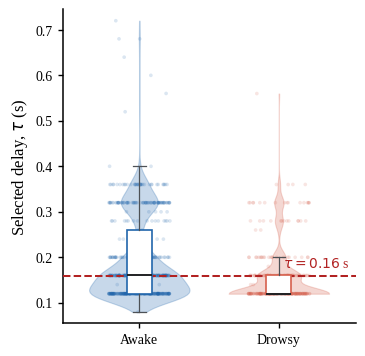

In [4]:
# Cell 4 — Publication Figure A: minimal all-window delay distribution by state
state_colors = {"Awake": "#2166ac", "Drowsy": "#d6604d"}
state_positions = {"Awake": 1, "Drowsy": 2}
state_arrays = [ami_scope.loc[ami_scope["label"].eq(state), "tau_seconds"].to_numpy(dtype=float) for state in AMI_STATES]
positions = [state_positions[state] for state in AMI_STATES]
fig, ax = plt.subplots(figsize=(3.54, 3.45), constrained_layout=True)
violins = ax.violinplot(state_arrays, positions=positions, vert=True, widths=0.72, showmeans=False, showmedians=False, showextrema=False, points=150, bw_method=0.22)
for body, state in zip(violins["bodies"], AMI_STATES):
    body.set_facecolor(state_colors[state]); body.set_edgecolor(state_colors[state]); body.set_alpha(0.25); body.set_linewidth(0.8)
rng = np.random.default_rng(20260829)
for state, values, position in zip(AMI_STATES, state_arrays, positions):
    jitter = rng.uniform(-0.22, 0.22, size=len(values))
    ax.scatter(position + jitter, values, s=7, color=state_colors[state], alpha=0.16, edgecolors="none", zorder=2)
box = ax.boxplot(state_arrays, positions=positions, vert=True, widths=0.18, patch_artist=True, showfliers=False, whis=1.5, zorder=4)
for patch, state in zip(box["boxes"], AMI_STATES):
    patch.set_facecolor("white"); patch.set_edgecolor(state_colors[state]); patch.set_linewidth(1.2)
for median in box["medians"]: median.set_color("#202124"); median.set_linewidth(1.4)
for artist in (*box["whiskers"], *box["caps"]): artist.set_color("#4d5156"); artist.set_linewidth(0.9)
ax.axhline(TAU_FINAL_S, color="#b22222", linestyle="--", linewidth=1.45, zorder=3)
ax.set_xticks(positions, AMI_STATES)
ax.set_xlim(0.45, 2.55)
all_tau_min = min(values.min() for values in state_arrays); all_tau_max = max(values.max() for values in state_arrays)
ax.set_ylim(all_tau_min - 0.025, all_tau_max + 0.025)
ax.set_ylabel(r"Selected delay, $\tau$ (s)")
ax.text(0.98, TAU_FINAL_S + 0.012, rf"$\tau={TAU_FINAL_S:.2f}$ s", transform=ax.get_yaxis_transform(), color="#b22222", va="bottom", ha="right", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
save_publication_figure(fig, "phase_space_ami_60s_processed")
plt.show()

### Cách đọc violin + box plot + raw points

- **Violin plot**: biểu diễn **hình dạng phân bố / mật độ** của dữ liệu.
  - vùng càng rộng → nhiều quan sát tập trung ở đó;
  - vùng càng hẹp → ít quan sát;
  - phần đuôi dài → tồn tại một số giá trị xa vùng tập trung chính.
  - Chiều rộng violin **không phải CI hay uncertainty**.

- **Box plot**:
  - cạnh dưới box = \(Q_1\) (25th percentile);
  - đường giữa box = **median** (50th percentile);
  - cạnh trên box = \(Q_3\) (75th percentile);
  - \(IQR = Q_3-Q_1\) → chứa **50% dữ liệu trung tâm**.

- **Whiskers**:
  - thường kéo đến các observation xa nhất còn nằm trong
    \(Q_1-1.5IQR\) và \(Q_3+1.5IQR\);
  - các điểm nằm ngoài vùng này có thể được xem là potential outliers.
  - Cần kiểm tra implementation thực tế vì `whis` có thể được cấu hình khác.

- **Raw/jittered points**:
  - mỗi điểm là một observation/window thực tế;
  - jitter chỉ để tránh chồng điểm, không mang ý nghĩa định lượng;
  - giúp cho thấy variability thực tế mà violin/box đã tóm tắt.

### Ý nghĩa khi kết hợp

`Raw points + violin + box plot`

→ cho thấy đồng thời:
1. dữ liệu gốc,
2. hình dạng phân bố,
3. median,
4. độ phân tán trung tâm qua IQR,
5. các giá trị cực trị/outlier.

### Cách giải thích Figure \(\tau\)

Violin cho thấy selected \(\tau\) tập trung chủ yếu ở vùng delay thấp ở cả Awake và Drowsy.  
Box plot tóm tắt median và 50% dữ liệu trung tâm, trong khi raw points cho thấy toàn bộ variability giữa các windows.  
Đường tham chiếu \(\tau=0.16\,s\) cho phép đánh giá vị trí của frozen delay so với phân bố thực nghiệm.

### Figure 1 — AMI-selected delay và lựa chọn \(\tau=0.16\,s\)

- Phân bố selected \(\tau\) của toàn bộ 60-s Processed PPG được trình bày riêng cho Awake và Drowsy.
- Cả hai trạng thái đều tập trung chủ yếu trong vùng delay ngắn, mặc dù Awake có độ phân tán lớn hơn và xuất hiện một số giá trị cao hơn.
- \(\tau=0.16\,s\) nằm trong vùng có mật độ cao của cả hai trạng thái và được chọn làm **common frozen delay** cho toàn bộ downstream analyses.
- Lựa chọn này ưu tiên một reconstruction thống nhất giữa states và sessions thay vì tối ưu riêng cho từng window.

- Việc chọn \(\tau\) là một trade-off giữa **temporal redundancy** khi delay quá ngắn và **dynamical irrelevance** khi delay quá dài.
- Với dataset hiện tại, \(\tau=0.12\,s\) tương ứng 3 samples ở phần lớn session ~25 Hz, trong khi \(\tau=0.16\,s\) tương ứng 4 samples; chi tiết này chỉ là một yếu tố thực dụng hỗ trợ lựa chọn, không phải tiêu chí lý thuyết độc lập.
- \(\tau=0.16\,s\) được ưu tiên chủ yếu vì nó là một **common conservative delay** hợp lý trên toàn bộ 20 sessions và cả hai trạng thái, đồng thời giữ temporal separation lớn hơn so với 0.12 s mà chưa đi quá xa như 0.20 s.
- Một quan sát hỗ trợ là \(\tau=0.16\,s\) nằm đúng giữa hai candidate lân cận \(0.12\,s\) và \(0.20\,s\). Điều này phù hợp với cách xem \(0.16\,s\) như một **trade-off trung tâm** giữa delay ngắn hơn (nguy cơ redundancy) và delay dài hơn (nguy cơ dynamical irrelevance), thay vì coi nó là một optimum tuyệt đối.
### Biện luận lựa chọn delay \(\tau\)

- **\(\tau = 0.12\,s\)**  
  Gần với AMI-selected delay của nhiều window hơn, đặc biệt ở Drowsy, nhưng ở ~25 Hz chỉ tương ứng **3 samples**. Delay ngắn như vậy làm các tọa độ embedding gần nhau hơn về thời gian, tăng nguy cơ **redundancy** và làm embedding span với \(m=8\) chỉ còn **0.84 s**.

- **\(\tau = 0.16\,s\)**  
  Tương ứng **4 samples ở 25 Hz** và **8 samples ở 50 Hz**; embedding span là **1.12 s**. Đây là lựa chọn **trade-off/consensus**: vẫn nằm trong vùng AMI hợp lý của cả Awake và Drowsy, cân bằng hơn giữa hai trạng thái, đồng thời tăng temporal separation so với 0.12 s. Vì vậy được freeze làm common delay cho toàn bộ downstream analyses.

- **\(\tau = 0.20\,s\)**  
  Cho temporal separation lớn hơn và embedding span **1.40 s**, nhưng bắt đầu lệch xa hơn khỏi AMI-selected delay, đặc biệt ở Drowsy. Nguy cơ lúc này là **over-delaying**, làm các tọa độ ít liên hệ động lực học ngắn hạn hơn cần thiết.

**Kết luận:**  
\(\tau = 0.16\,s\) không phải optimum tuyệt đối, mà là **common conservative trade-off giữa redundancy ở delay quá nhỏ và irrelevance ở delay quá lớn**, đồng thời giữ reconstruction nhất quán giữa sessions và states.

In [5]:
# Cell 7 — Session-level FNN evidence for the frozen embedding dimension
fnn_session_curves = fnn_scope.groupby(["session", "dimension"])["fnn_percent"].median().unstack("dimension")
fnn_session_curves = fnn_session_curves.loc[sorted(fnn_session_curves.index, key=session_number), sorted(fnn_session_curves.columns)]
require(fnn_session_curves.notna().all().all(), "Session-level FNN curve matrix is incomplete.")
for needed_dimension in (M_FINAL - 1, M_FINAL, M_FINAL + 1):
    require(needed_dimension in fnn_session_curves.columns, f"FNN evidence requires m={needed_dimension}.")

fnn_dimension_summary = pd.DataFrame({
    "dimension": fnn_session_curves.columns.astype(int),
    "median_fnn_percent": fnn_session_curves.median(axis=0).to_numpy(),
    "q25_fnn_percent": fnn_session_curves.quantile(0.25, axis=0).to_numpy(),
    "q75_fnn_percent": fnn_session_curves.quantile(0.75, axis=0).to_numpy(),
    "min_fnn_percent": fnn_session_curves.min(axis=0).to_numpy(),
    "max_fnn_percent": fnn_session_curves.max(axis=0).to_numpy(),
})
fnn_at_m = fnn_session_curves[M_FINAL]
fnn_m_median = float(fnn_at_m.median())
fnn_m_q25, fnn_m_q75 = np.percentile(fnn_at_m, [25, 75])
n_low_fnn = int(fnn_at_m.le(FNN_LOW_THRESHOLD_PCT).sum())
reduction_7_to_8 = fnn_session_curves[M_FINAL - 1] - fnn_session_curves[M_FINAL]
reduction_8_to_9 = fnn_session_curves[M_FINAL] - fnn_session_curves[M_FINAL + 1]
later_dimensions = [dimension for dimension in fnn_session_curves.columns if dimension > M_FINAL]
require(later_dimensions, "No dimensions beyond frozen m are available for the marginal-gain audit.")
best_later_reduction = fnn_session_curves[M_FINAL] - fnn_session_curves[later_dimensions].min(axis=1)
fnn_reduction_7_to_8_median = float(reduction_7_to_8.median())
fnn_reduction_8_to_9_median = float(reduction_8_to_9.median())
fnn_best_later_reduction_median = float(best_later_reduction.median())

FNN_STATES = ["Awake", "Drowsy"]
available_fnn_states = set(fnn_scope["label"].astype(str))
require(set(FNN_STATES).issubset(available_fnn_states), f"FNN state coverage is incomplete: {available_fnn_states}")
fnn_state_window_counts = (
    fnn_scope[["label", "session", "window_id"]].drop_duplicates()
    .groupby("label").size().reindex(FNN_STATES).astype(int)
)
fnn_state_session_curves = {}
state_curve_rows = []
state_summary_rows = []
state_metric_rows = []
for state in FNN_STATES:
    matrix = (
        fnn_scope.loc[fnn_scope["label"].eq(state)]
        .groupby(["session", "dimension"])["fnn_percent"].median().unstack("dimension")
    )
    matrix = matrix.loc[sorted(matrix.index, key=session_number), sorted(matrix.columns)]
    require(len(matrix) == N_SESSIONS_EXPECTED, f"{state} FNN curves cover {len(matrix)} sessions; expected {N_SESSIONS_EXPECTED}.")
    require(matrix.notna().all().all(), f"{state} session-level FNN curve matrix is incomplete.")
    fnn_state_session_curves[state] = matrix
    for session, curve in matrix.iterrows():
        for dimension, value in curve.items():
            state_curve_rows.append({"state": state, "session": session, "dimension": int(dimension), "median_fnn_percent": float(value)})
    for dimension in matrix.columns:
        values = matrix[dimension]
        state_summary_rows.append({
            "state": state, "dimension": int(dimension),
            "median_fnn_percent": float(values.median()),
            "q25_fnn_percent": float(values.quantile(0.25)),
            "q75_fnn_percent": float(values.quantile(0.75)),
            "min_fnn_percent": float(values.min()),
            "max_fnn_percent": float(values.max()),
        })
    state_metric_rows.append({
        "state": state,
        "n_windows": int(fnn_state_window_counts.loc[state]),
        "n_sessions": int(len(matrix)),
        "fnn_median_at_m8_percent": float(matrix[M_FINAL].median()),
        "fnn_q25_at_m8_percent": float(matrix[M_FINAL].quantile(0.25)),
        "fnn_q75_at_m8_percent": float(matrix[M_FINAL].quantile(0.75)),
        "median_reduction_m8_to_m9_pp": float((matrix[M_FINAL] - matrix[M_FINAL + 1]).median()),
    })
fnn_session_state_curves = pd.DataFrame(state_curve_rows)
fnn_state_dimension_summary = pd.DataFrame(state_summary_rows)
fnn_state_metrics = pd.DataFrame(state_metric_rows).set_index("state")

fnn_session_curves.rename_axis(columns="dimension").stack().rename("median_fnn_percent").reset_index().to_csv(TABLE_DIR / "fnn_session_curves.csv", index=False)
fnn_dimension_summary.to_csv(TABLE_DIR / "fnn_dimension_summary.csv", index=False)
fnn_session_state_curves.to_csv(TABLE_DIR / "fnn_session_state_curves.csv", index=False)
fnn_state_dimension_summary.to_csv(TABLE_DIR / "fnn_state_dimension_summary.csv", index=False)
fnn_state_metrics.reset_index().to_csv(TABLE_DIR / "fnn_state_metrics.csv", index=False)

print(f"FNN evidence at frozen m={M_FINAL}")
print(f"  Median: {fnn_m_median:.3f}%")
print(f"  IQR: {fnn_m_q25:.3f}–{fnn_m_q75:.3f}%")
print(f"  Sessions at or below {FNN_LOW_THRESHOLD_PCT:.1f}%: {n_low_fnn}/{len(fnn_at_m)}")
print(f"  Median reduction m=7→8: {fnn_reduction_7_to_8_median:+.3f} percentage points")
print(f"  Median reduction m=8→9: {fnn_reduction_8_to_9_median:+.3f} percentage points")
print(f"  Median best reduction at any available m>8: {fnn_best_later_reduction_median:+.3f} percentage points")
print("  Sign convention: positive values are reductions in FNN.")
for state in FNN_STATES:
    row = fnn_state_metrics.loc[state]
    print(f"  {state}: {int(row['n_windows'])} windows from {int(row['n_sessions'])} sessions; FNN at m=8 {row['fnn_median_at_m8_percent']:.3f}% (IQR {row['fnn_q25_at_m8_percent']:.3f}–{row['fnn_q75_at_m8_percent']:.3f}%); m=8→9 reduction {row['median_reduction_m8_to_m9_pp']:+.3f} pp")
print("  Interpretation: FNN enters the low plateau by approximately m=6–8. Frozen m=8 is a common conservative dimension, not a unique elbow; higher tested dimensions do not produce a consistent practical reduction.")
display(fnn_state_metrics.reset_index(), fnn_state_dimension_summary)

FNN evidence at frozen m=8
  Median: 0.886%
  IQR: 0.613–1.132%
  Sessions at or below 1.0%: 11/20
  Median reduction m=7→8: -0.002 percentage points
  Median reduction m=8→9: -0.088 percentage points
  Median best reduction at any available m>8: -0.073 percentage points
  Sign convention: positive values are reductions in FNN.
  Awake: 596 windows from 20 sessions; FNN at m=8 0.851% (IQR 0.528–1.175%); m=8→9 reduction -0.072 pp
  Drowsy: 305 windows from 20 sessions; FNN at m=8 0.988% (IQR 0.732–1.158%); m=8→9 reduction -0.071 pp
  Interpretation: FNN enters the low plateau by approximately m=6–8. Frozen m=8 is a common conservative dimension, not a unique elbow; higher tested dimensions do not produce a consistent practical reduction.


,state,n_windows,n_sessions,fnn_median_at_m8_percent,fnn_q25_at_m8_percent,fnn_q75_at_m8_percent,median_reduction_m8_to_m9_pp
0,Awake,596,20,0.851499,0.527929,1.175068,-0.071563
1,Drowsy,305,20,0.987738,0.732289,1.158038,-0.071377


,state,dimension,median_fnn_percent,q25_fnn_percent,q75_fnn_percent,min_fnn_percent,max_fnn_percent
0,Awake,1,95.889037,95.354278,96.164773,94.919786,97.042112
1,Awake,2,31.780169,30.060322,33.679625,26.206434,36.595174
2,Awake,3,6.485215,6.165995,6.838038,4.875588,7.963710
3,Awake,4,2.198450,1.819407,2.847035,1.180040,3.234501
4,Awake,5,1.283784,0.996622,1.494932,0.574324,1.756757
5,Awake,6,1.016260,0.745257,1.185637,0.254065,1.422764
6,Awake,7,0.900136,0.577446,1.129416,0.220788,1.290761
7,Awake,8,0.851499,0.527929,1.175068,0.170300,1.294278
8,Awake,9,0.905055,0.665984,1.306352,0.204918,1.434426
9,Awake,10,1.113014,0.650685,1.455479,0.273973,1.746575


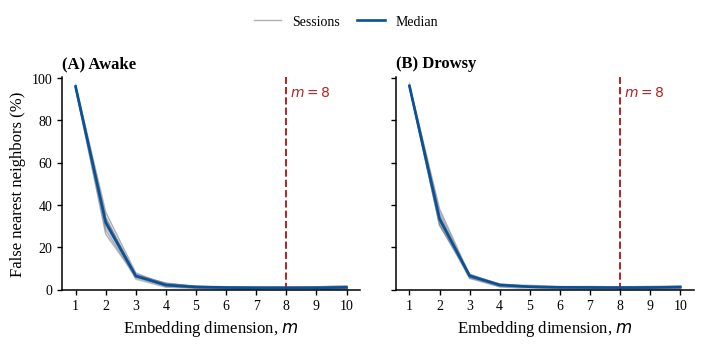

In [6]:
# Cell 8 — Publication Figure B: state-specific FNN evidence for one common dimension
dims = fnn_session_curves.columns.to_numpy(dtype=int)
fig, axes = plt.subplots(1, 2, figsize=(7.10, 3.55), sharex=True, sharey=True)
global_fnn_max = max(float(matrix.to_numpy().max()) for matrix in fnn_state_session_curves.values())
for panel_index, (ax, state) in enumerate(zip(axes, FNN_STATES)):
    matrix = fnn_state_session_curves[state]
    state_summary = fnn_state_dimension_summary.loc[fnn_state_dimension_summary["state"].eq(state)].set_index("dimension").loc[dims]
    state_median = state_summary["median_fnn_percent"].to_numpy()
    for _, curve in matrix.iterrows():
        ax.plot(dims, curve.to_numpy(), color="#7f858b", alpha=0.40, linewidth=1.0, zorder=1)
    ax.plot(dims, state_median, color="#08519c", alpha=1.0, linewidth=1.9, zorder=3)
    ax.axvline(M_FINAL, color="#b22222", linestyle="--", linewidth=1.40, zorder=2)
    ax.set_xlim(dims.min() - 0.45, dims.max() + 0.45)
    ax.set_ylim(0, max(100.0, 1.03 * global_fnn_max))
    ax.set_xlabel(r"Embedding dimension, $m$")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(0.00, 1.025, f"({'AB'[panel_index]}) {state}", transform=ax.transAxes, va="bottom", ha="left", fontsize=12, fontweight="bold")
    ax.text(M_FINAL + 0.12, 0.96, rf"$m={M_FINAL}$", transform=ax.get_xaxis_transform(), color="#b22222", va="top", ha="left", fontsize=10)
axes[0].set_ylabel("False nearest neighbors (%)")
fig.subplots_adjust(left=0.10, right=0.99, bottom=0.20, top=0.80, wspace=0.12)
fig.legend(handles=[
    Line2D([0], [0], color="#7f858b", alpha=0.65, linewidth=1.0, label="Sessions"),
    Line2D([0], [0], color="#08519c", alpha=1.0, linewidth=1.9, label="Median"),
], frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.50, 0.99), handlelength=2.0, borderaxespad=0.0, columnspacing=1.2)
save_publication_figure(fig, "phase_space_fnn_60s_processed")
plt.show()

### Figure 2 — False Nearest Neighbors và lựa chọn \(m=8\)

- FNN giảm rất nhanh khi tăng \(m\), đặc biệt từ \(m=1\) đến khoảng \(m=4-5\), ở cả Awake và Drowsy.
- Từ khoảng \(m \ge 5\), FNN đi vào vùng thấp và gần plateau; đến \(m=8\), residual false neighbors đã rất nhỏ trên hầu hết 20 sessions.
- Tăng tiếp lên \(m=9-10\) chỉ đem lại cải thiện nhỏ, trong khi làm tăng dimensionality và chi phí tính toán.
- Vì vậy, \(m=8\) được freeze như một **conservative common embedding dimension** cho cả hai trạng thái.

**Biện luận thống kê**
- **Median** được dùng để mô tả hành vi điển hình giữa các session và giảm ảnh hưởng của các session cực trị.
- **IQR** biểu diễn mức phân tán của 50% session trung tâm, giúp đánh giá độ nhất quán giữa các session.
- Median + IQR phù hợp hơn mean ± SD khi phân bố FNN giữa các session có thể lệch hoặc chứa outlier.

In [7]:
# Cell 9 — Machine-readable evidence ledger for the frozen reconstruction
evidence_ledger = pd.DataFrame([
    {
        "parameter": "Delay tau", "frozen_value": f"{TAU_FINAL_S:.2f} s", "method": "AMI selected delay",
        "session_level_evidence": f"{len(ami_scope)} windows/20 sessions: Awake n={int(ami_state_lookup.loc['Awake', 'n_windows'])}, median {ami_state_lookup.loc['Awake', 'tau_median_s']:.3f} s; Drowsy n={int(ami_state_lookup.loc['Drowsy', 'n_windows'])}, median {ami_state_lookup.loc['Drowsy', 'tau_median_s']:.3f} s; pooled session median {ami_overall_median:.3f} s; paired Drowsy−Awake median {paired_tau_difference_median:+.3f} s",
        "interpretation": "All-window state distributions and paired summaries across all 20 sessions support a consensus common delay; this is not per-window, per-session, or per-state optimization.",
        "downstream_use": "Common time delay for all 60-s Processed PPG embeddings",
    },
    {
        "parameter": "Embedding dimension m", "frozen_value": str(M_FINAL), "method": "False nearest neighbors",
        "session_level_evidence": f"20 sessions/state: Awake n={int(fnn_state_metrics.loc['Awake', 'n_windows'])}, median FNN@8 {fnn_state_metrics.loc['Awake', 'fnn_median_at_m8_percent']:.3f}%; Drowsy n={int(fnn_state_metrics.loc['Drowsy', 'n_windows'])}, median FNN@8 {fnn_state_metrics.loc['Drowsy', 'fnn_median_at_m8_percent']:.3f}%; m=8→9 reductions {fnn_state_metrics.loc['Awake', 'median_reduction_m8_to_m9_pp']:+.3f}/{fnn_state_metrics.loc['Drowsy', 'median_reduction_m8_to_m9_pp']:+.3f} pp",
        "interpretation": "Both states enter a similar low-FNN plateau; m=8 is a stability-and-uniformity trade-off for one comparable downstream embedding, not a unique elbow.",
        "downstream_use": "Common embedding dimension for all 60-s Processed PPG embeddings",
    },
])
evidence_ledger.to_csv(TABLE_DIR / "phase_space_reconstruction_summary.csv", index=False)
display(evidence_ledger)
print(
    f"For the primary scope ({REPRESENTATION} PPG, {WINDOW_SIZE_S}-s windows), embedding parameters were selected from all {len(ami_scope)} eligible Awake and Drowsy windows across {N_SESSIONS_EXPECTED} sessions.\n"
    f"AMI evidence combined the all-window state distributions with paired session medians. The pooled across-session median was {ami_overall_median:.3f} s, while the paired Drowsy−Awake median difference was {paired_tau_difference_median:+.3f} s, supporting frozen tau={TAU_FINAL_S:.2f} s as a consensus delay.\n"
    f"At m={M_FINAL}, median session-level FNN was {fnn_state_metrics.loc['Awake', 'fnn_median_at_m8_percent']:.3f}% in Awake and {fnn_state_metrics.loc['Drowsy', 'fnn_median_at_m8_percent']:.3f}% in Drowsy. Neither state showed a median reduction at m=9, supporting m={M_FINAL} as a conservative common dimension within the low-FNN plateau.\n"
    "Parameters were not tuned separately by window, session, or state; they were frozen to prioritize methodological consistency and cross-session/state comparability over local optimality."
)

,parameter,frozen_value,method,session_level_evidence,interpretation,downstream_use
0,Delay tau,0.16 s,AMI selected delay,"901 windows/20 sessions: Awake n=596, median 0...",All-window state distributions and paired summ...,Common time delay for all 60-s Processed PPG e...
1,Embedding dimension m,8,False nearest neighbors,"20 sessions/state: Awake n=596, median FNN@8 0...",Both states enter a similar low-FNN plateau; m...,Common embedding dimension for all 60-s Proces...


For the primary scope (Processed PPG, 60-s windows), embedding parameters were selected from all 901 eligible Awake and Drowsy windows across 20 sessions.
AMI evidence combined the all-window state distributions with paired session medians. The pooled across-session median was 0.160 s, while the paired Drowsy−Awake median difference was +0.000 s, supporting frozen tau=0.16 s as a consensus delay.
At m=8, median session-level FNN was 0.851% in Awake and 0.988% in Drowsy. Neither state showed a median reduction at m=9, supporting m=8 as a conservative common dimension within the low-FNN plateau.
Parameters were not tuned separately by window, session, or state; they were frozen to prioritize methodological consistency and cross-session/state comparability over local optimality.


In [8]:
# Cell 10 — Deterministic, same-session representative Awake/Drowsy selection
def morphology_features(signal: np.ndarray) -> np.ndarray:
    """Predeclared centrality features; selection never uses visual appearance."""
    signal = np.asarray(signal, dtype=float)
    differences = np.diff(signal)
    return np.array([np.std(signal, ddof=1), np.percentile(signal, 75) - np.percentile(signal, 25), np.sqrt(np.mean(differences**2)), skew(signal, bias=False), kurtosis(signal, fisher=True, bias=False)], dtype=float)


def robust_centrality(feature_matrix: np.ndarray) -> np.ndarray:
    center = np.median(feature_matrix, axis=0)
    scale = np.percentile(feature_matrix, 75, axis=0) - np.percentile(feature_matrix, 25, axis=0)
    scale = np.where(scale > np.finfo(float).eps, scale, 1.0)
    return np.sqrt(np.mean(((feature_matrix - center) / scale) ** 2, axis=1))


window_records = []
for npz_path in sorted(SEGMENTED_DIR.glob("sample_*.npz"), key=lambda path: session_number(path.stem)):
    with np.load(npz_path, allow_pickle=False) as data:
        required_keys = {"fs", "60/processed", "60/window_id", "60/label", "60/stationarity_score_processed", "60/stationarity_pass_processed"}
        require(required_keys.issubset(data.files), f"{npz_path.name} missing keys: {sorted(required_keys-set(data.files))}")
        signals, window_ids, labels = data["60/processed"], data["60/window_id"], data["60/label"]
        scores, passes, fs = data["60/stationarity_score_processed"], data["60/stationarity_pass_processed"], float(data["fs"])
        require(len(signals) == len(window_ids) == len(labels) == len(scores) == len(passes), f"Misaligned arrays in {npz_path.name}.")
        for signal, window_id, label, stationarity_score, stationarity_pass in zip(signals, window_ids, labels, scores, passes):
            valid = bool(stationarity_pass) and np.isfinite(signal).all() and np.ptp(signal) > 0
            if valid and int(label) in (0, 1):
                window_records.append({
                    "session": npz_path.stem, "npz_path": npz_path, "window_id": int(window_id), "label": int(label),
                    "state": "Awake" if int(label) == 0 else "Drowsy", "fs": fs,
                    "stationarity_score": float(stationarity_score), "signal": np.asarray(signal, dtype=float), "features": morphology_features(signal),
                })

require(window_records, "No valid 60-s Processed windows were found in segmented NPZ files.")
counts = pd.DataFrame([{"session": record["session"], "label": record["label"]} for record in window_records]).value_counts(["session", "label"]).unstack(fill_value=0)
for state_label in (0, 1):
    if state_label not in counts.columns:
        counts[state_label] = 0
counts = counts[[0, 1]].rename(columns={0: "n_awake", 1: "n_drowsy"})
candidate_counts = counts[(counts["n_awake"] > 0) & (counts["n_drowsy"] > 0)].copy()
require(len(candidate_counts) > 0, "No session contains valid windows from both states.")
candidate_counts["min_state_count"] = candidate_counts[["n_awake", "n_drowsy"]].min(axis=1)
candidate_counts["total_count"] = candidate_counts[["n_awake", "n_drowsy"]].sum(axis=1)
candidate_counts["session_number"] = [session_number(session) for session in candidate_counts.index]
REPRESENTATIVE_SESSION = "sample_1"  # frozen visualization choice requested for a smoother trajectory
require(REPRESENTATIVE_SESSION in candidate_counts.index, f"{REPRESENTATIVE_SESSION} does not contain valid windows from both states.")
selected_session = REPRESENTATIVE_SESSION

selected_records = []
feature_names = ["signal_sd", "signal_iqr", "rmssd", "skewness", "excess_kurtosis"]
for label, state in ((0, "Awake"), (1, "Drowsy")):
    candidates = [r for r in window_records if r["session"] == selected_session and r["label"] == label]
    matrix = np.vstack([record["features"] for record in candidates])
    distances = robust_centrality(matrix)
    best_index = min(range(len(candidates)), key=lambda idx: (distances[idx], candidates[idx]["window_id"]))
    chosen = candidates[best_index].copy()
    chosen["centrality_distance"] = float(distances[best_index])
    selected_records.append(chosen)

selection_rows = []
for record in selected_records:
    row = {
        "session": record["session"], "window_id": record["window_id"], "state": record["state"], "fs_hz": record["fs"],
        "stationarity_score_processed": record["stationarity_score"], "centrality_distance": record["centrality_distance"],
        "selection_rule": "session sample_1 fixed a priori; minimum robust within-state morphology distance",
    }
    row.update(dict(zip(feature_names, record["features"])))
    selection_rows.append(row)
selection_table = pd.DataFrame(selection_rows)
selection_table.to_csv(TABLE_DIR / "representative_windows.csv", index=False)
print("Selection rule (declared before visualization): use the requested session sample_1; within each state choose the window nearest the robust median of SD, IQR, RMSSD, skewness, and excess kurtosis.")
print(f"Selected same-session comparison: {selected_session}")
display(selection_table)

Selection rule (declared before visualization): use the requested session sample_1; within each state choose the window nearest the robust median of SD, IQR, RMSSD, skewness, and excess kurtosis.
Selected same-session comparison: sample_1


,session,window_id,state,fs_hz,stationarity_score_processed,centrality_distance,selection_rule,signal_sd,signal_iqr,rmssd,skewness,excess_kurtosis
0,sample_1,7,Awake,50.0,0.178576,0.192973,session sample_1 fixed a priori; minimum robus...,163.768618,277.885114,40.561346,-0.401523,-1.083665
1,sample_1,25,Drowsy,50.0,0.381939,0.000000,session sample_1 fixed a priori; minimum robus...,111.544951,184.453425,26.307162,-0.537687,-0.870681


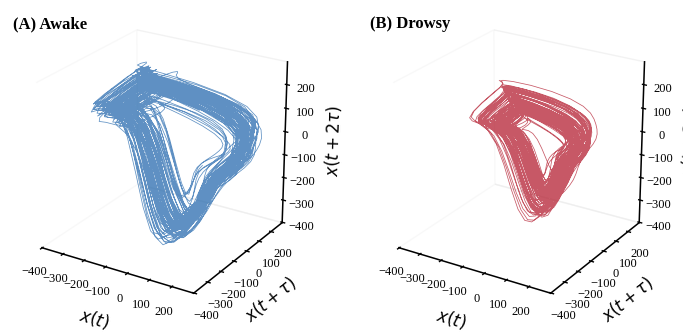

Awake: sample_1, window 7, fs=50.000 Hz, tau=8 samples (0.160 s), full embedding=(2944, 8)
Drowsy: sample_1, window 25, fs=50.000 Hz, tau=8 samples (0.160 s), full embedding=(2944, 8)
Figure C is a qualitative 3D projection [x(t), x(t+tau), x(t+2tau)] of the full m=8 embedding using unnormalized Processed PPG amplitudes. Both panels use identical axis limits, camera angle, and line settings; no quantitative state difference is inferred from this visualization alone.


In [9]:
# Cell 11 — Publication Figure C: 3D projection of the full m=8 reconstruction
def reconstruct_phase_space(signal: np.ndarray, dimension: int, delay_samples: int) -> np.ndarray:
    signal = np.asarray(signal, dtype=float)
    require(signal.ndim == 1 and np.isfinite(signal).all(), "Embedding input must be a finite 1D signal.")
    require(isinstance(dimension, (int, np.integer)) and dimension >= 2, "dimension must be an integer >=2.")
    require(isinstance(delay_samples, (int, np.integer)) and delay_samples >= 1, "delay_samples must be an integer >=1.")
    n_vectors = len(signal) - (dimension - 1) * delay_samples
    require(n_vectors > 0, "Signal is too short for the requested embedding.")
    return np.column_stack([signal[offset:offset + n_vectors] for offset in range(0, dimension * delay_samples, delay_samples)])


embeddings, projection_frames = [], []
for record in selected_records:
    delay_samples = int(round(TAU_FINAL_S * record["fs"]))
    realized_tau_s = delay_samples / record["fs"]
    require(abs(realized_tau_s - TAU_FINAL_S) <= 0.5 / record["fs"] + 1e-12, "Frozen delay cannot be represented within half a sample.")
    embedding = reconstruct_phase_space(record["signal"], M_FINAL, delay_samples)
    projection = embedding[:, :3]
    embeddings.append({**record, "delay_samples": delay_samples, "realized_tau_s": realized_tau_s, "embedding": embedding, "projection": projection})
    projection_frames.append(pd.DataFrame({
        "session": record["session"], "window_id": record["window_id"], "state": record["state"],
        "vector_index": np.arange(len(projection)), "x_t": projection[:, 0], "x_t_plus_tau": projection[:, 1], "x_t_plus_2tau": projection[:, 2],
    }))
pd.concat(projection_frames, ignore_index=True).to_csv(PROJECTION_DIR / "representative_phase_space_projection.csv", index=False)

all_coordinates = np.concatenate([item["projection"].ravel() for item in embeddings])
axis_min, axis_max = float(all_coordinates.min()), float(all_coordinates.max())
padding = 0.04 * (axis_max - axis_min)
shared_limits = (axis_min - padding, axis_max + padding)

fig = plt.figure(figsize=(7.1, 3.70), constrained_layout=False)
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.14, top=0.95, wspace=0.10)
colors = {"Awake": "#2166ac", "Drowsy": "#b2182b"}
for panel_index, item in enumerate(embeddings, start=1):
    ax = fig.add_subplot(1, 2, panel_index, projection="3d")
    projection = item["projection"]
    ax.plot(projection[:, 0], projection[:, 1], projection[:, 2], color=colors[item["state"]], linewidth=0.55, alpha=0.72, rasterized=True)
    ax.set_xlim(shared_limits); ax.set_ylim(shared_limits); ax.set_zlim(shared_limits)
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=24, azim=-58)
    ax.set_xlabel(r"$x(t)$ ", labelpad=2); ax.set_ylabel(r"$x(t+\tau)$ ", labelpad=2); ax.set_zlabel(r"$x(t+2\tau)$ ", labelpad=2)
    ax.tick_params(labelsize=9, pad=1); ax.grid(False)
    ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
    ax.text2D(0.01, 0.98, f"({'AB'[panel_index-1]}) {item['state']}", transform=ax.transAxes, va="top", fontsize=12, fontweight="bold")

save_publication_figure(fig, "phase_space_reconstruction_awake_drowsy")
plt.show()
for item in embeddings:
    print(f"{item['state']}: {item['session']}, window {item['window_id']}, fs={item['fs']:.3f} Hz, tau={item['delay_samples']} samples ({item['realized_tau_s']:.3f} s), full embedding={item['embedding'].shape}")
print(f"Figure C is a qualitative 3D projection [x(t), x(t+tau), x(t+2tau)] of the full m={M_FINAL} embedding using unnormalized Processed PPG amplitudes. Both panels use identical axis limits, camera angle, and line settings; no quantitative state difference is inferred from this visualization alone.")

### Figure 3 — Reconstructed phase-space visualization

- Hình biểu diễn **3D projection** của reconstructed state space sử dụng frozen embedding:
  - \(m = 8\)
  - \(\tau = 0.16\,s\)
- Hai panel Awake và Drowsy được hiển thị với cùng hệ trục và cùng góc nhìn để bảo đảm khả năng so sánh trực quan.
- Cả hai trạng thái đều cho thấy quỹ đạo có cấu trúc rõ ràng thay vì phân bố ngẫu nhiên trong không gian trạng thái.
- Drowsy có xu hướng xuất hiện **compact / overlapped hơn**, với trajectory tập trung dày hơn ở một số vùng so với Awake.
- Quan sát này chỉ mang tính **qualitative visualization**; không dùng riêng figure để suy luận state effect.
- Các khác biệt hình học được định lượng ở downstream analyses bằng RQA và LLE.

# CONCLUSION

## Frozen Phase-Space Reconstruction Foundation

### 1. AMI — Delay selection
- Primary scope: 60-s Processed PPG, 20 sessions, Awake + Drowsy.
- Frozen delay: \(\tau = 0.16\,s\).
- \(\tau=0.16\,s\) được xem là **common conservative trade-off**, không phải optimum tuyệt đối cho mọi window.
- Lựa chọn cân bằng giữa:
  - redundancy khi delay quá ngắn;
  - dynamical irrelevance khi delay quá dài;
  - consistency giữa states/sessions;
  - nhu cầu sử dụng một reconstruction chung cho downstream analyses.

### 2. FNN — Embedding dimension
- Frozen dimension: \(m=8\).
- FNN giảm mạnh khi tăng \(m\), sau đó đi vào vùng thấp/plateau ở cả Awake và Drowsy.
- \(m=8\) nằm trong vùng residual FNN rất thấp trên toàn bộ sessions.
- Tăng thêm dimension chỉ cải thiện ít nhưng làm tăng dimensionality và computational cost.
- Vì vậy \(m=8\) là **conservative common embedding dimension**.

### 3. Phase-Space Reconstruction visualization
- Reconstructed using \(m=8,\ \tau=0.16\,s\).
- 3D projections cho thấy structured state-space trajectories ở cả Awake và Drowsy.
- Drowsy có xu hướng compact/overlapped hơn về mặt trực quan.
- PSR figure chỉ mang tính qualitative; state-dependent inference được giao cho RQA/LLE.

### Frozen conclusion
For all downstream nonlinear analyses:

\[
\boxed{m=8,\qquad \tau=0.16\,s}
\]

Các tham số được freeze trước khi diễn giải Simplex, RQA và LLE nhằm bảo đảm methodological consistency và comparability giữa sessions/states.